In [ ]:
# Install / Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Load your engineered dataset
df = pd.read_csv("project_folder/PEM_Data_Engineered_Features.csv")

# Quick check
print("Shape:", df.shape)
df.head()


Shape: (500, 28)


,Operating_Temperature_C,Current_Density_mA_cm2,Cell_Voltage_V,Cathode_Pressure_bar,Anode_Pressure_bar,Anode_Catalyst_Type,Anode_Catalyst_Loading_mg_cm2,Cathode_Catalyst_Type,Cathode_Catalyst_Loading_mg_cm2,Membrane_Type,...,Temp_x_CurrentDensity,CurrentDensity_per_MembraneThickness,Pressure_Differential,Anode_Catalyst_Activity,Membrane_Resistance_Index,Power_per_Temperature,Cathode_Catalyst_Efficiency,Voltage_per_Temperature,Current_Efficiency,Total_Catalyst_Loading
0,55.45,3796.49,2.24,8.20,2.45,Ir_black,2.87,Pt/C,0.11,Nafion_117,...,210515.3705,21.783854,5.75,4.996872,10.511460,0.153111,0.9020,0.040397,0.174121,2.98
1,74.79,3028.51,1.96,21.30,2.22,IrRuOx,1.15,Pt/C,0.10,Nafion_115,...,226502.2629,23.100763,19.08,2.429443,7.259136,0.079556,2.1300,0.026207,0.174122,1.25
2,67.56,2154.79,1.86,20.26,2.54,IrO2,2.11,Pt/C,0.13,Nafion_212,...,145577.6124,43.260189,17.72,4.146597,2.226643,0.059207,2.6338,0.027531,0.174119,2.24
3,63.49,4483.86,2.41,18.74,3.56,IrO2,1.57,Pt/C,0.29,Nafion_212,...,284680.2714,89.284349,15.18,2.962329,2.768467,0.170106,5.4346,0.037959,0.174120,1.86
4,44.65,3725.99,2.25,4.83,2.18,IrO2,1.82,Pt/C,0.17,Nafion_117,...,166365.4535,20.657482,2.65,2.844355,7.747852,0.187682,0.8211,0.050392,0.174120,1.99


In [ ]:
# Encode categorical columns into dummy variables (0/1)
df_encoded = pd.get_dummies(
    df,
    columns=["Anode_Catalyst_Type", "Cathode_Catalyst_Type", "Membrane_Type"],
    drop_first=True
)

print("Shape after encoding:", df_encoded.shape)
print("Columns after encoding:", df_encoded.columns.tolist()[:15])  # show first 15


Shape after encoding: (500, 29)
Columns after encoding: ['Operating_Temperature_C', 'Current_Density_mA_cm2', 'Cell_Voltage_V', 'Cathode_Pressure_bar', 'Anode_Pressure_bar', 'Anode_Catalyst_Loading_mg_cm2', 'Cathode_Catalyst_Loading_mg_cm2', 'Membrane_Thickness_um', 'Membrane_Water_Content_lambda', 'Water_Flow_Rate_mL_min', 'Water_Flow_Rate_L_min', 'Power_Density_W_cm2', 'H2_Production_Rate_mL_min', 'H2_Production_Rate_NL_h', 'Energy_Efficiency_percent']


In [ ]:
# Features (X) = all except targets
X = df_encoded.drop(["Cell_Voltage_V","Energy_Efficiency_percent"], axis=1)

# Targets (y)
y_voltage = df_encoded["Cell_Voltage_V"]
y_eff = df_encoded["Energy_Efficiency_percent"]


In [ ]:
# Split into train/test sets
X_train, X_test, yv_train, yv_test = train_test_split(X, y_voltage, test_size=0.2, random_state=42)
_, _, ye_train, ye_test = train_test_split(X, y_eff, test_size=0.2, random_state=42)


In [ ]:
# Train Random Forest models
rf_voltage = RandomForestRegressor(random_state=42)
rf_voltage.fit(X_train, yv_train)

rf_eff = RandomForestRegressor(random_state=42)
rf_eff.fit(X_train, ye_train)


RandomForestRegressor(random_state=42)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Voltage model evaluation
yv_pred = rf_voltage.predict(X_test)
print("Voltage Model:")
print("  R²:", r2_score(yv_test, yv_pred))
print("  RMSE:", np.sqrt(mean_squared_error(yv_test, yv_pred)))   # <-- fixed
print("  MAE:", mean_absolute_error(yv_test, yv_pred))

# Efficiency model evaluation
ye_pred = rf_eff.predict(X_test)
print("\nEfficiency Model:")
print("  R²:", r2_score(ye_test, ye_pred))
print("  RMSE:", np.sqrt(mean_squared_error(ye_test, ye_pred)))   # <-- fixed
print("  MAE:", mean_absolute_error(ye_test, ye_pred))


Voltage Model:
  R²: 0.9811432982629861
  RMSE: 0.03875745992709001
  MAE: 0.029704999999999954

Efficiency Model:
  R²: 0.9776134500973281
  RMSE: 1.587573865966553
  MAE: 1.1887249999999931


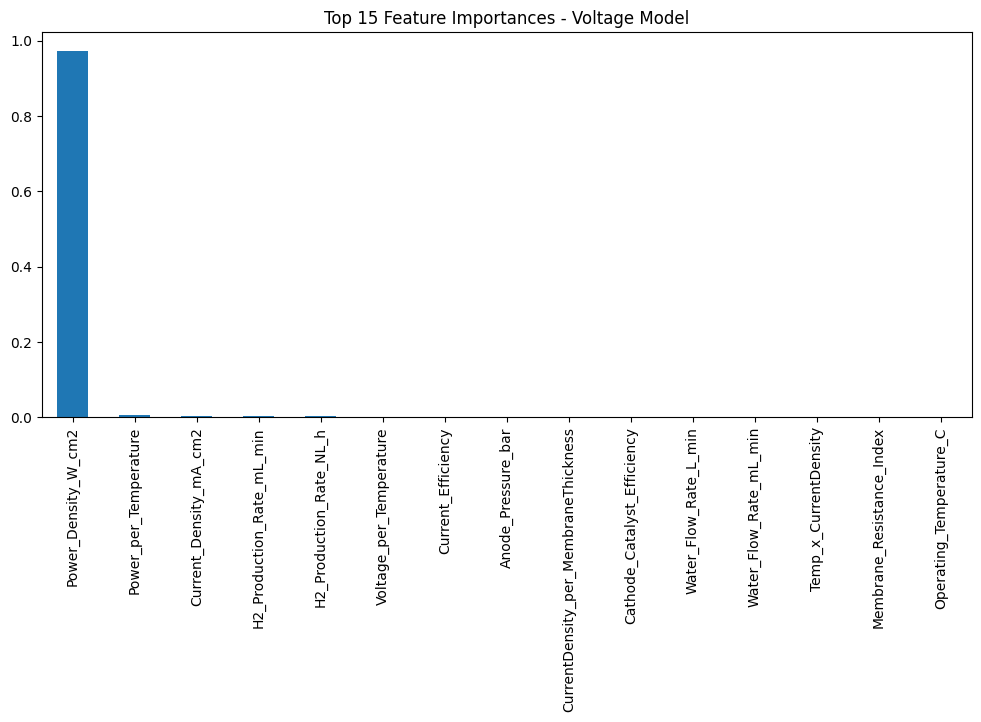

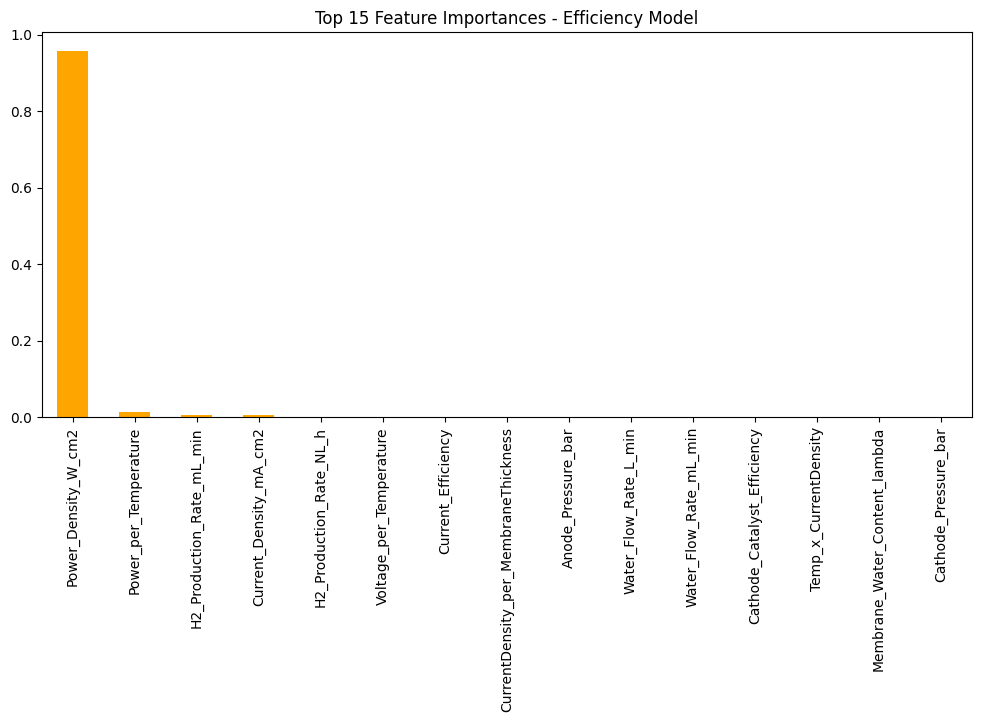

In [ ]:
# Voltage model feature importance
importances_v = pd.Series(rf_voltage.feature_importances_, index=X.columns)
importances_v.sort_values(ascending=False).head(15).plot(kind="bar", figsize=(12,5))
plt.title("Top 15 Feature Importances - Voltage Model")
plt.show()

# Efficiency model feature importance
importances_e = pd.Series(rf_eff.feature_importances_, index=X.columns)
importances_e.sort_values(ascending=False).head(15).plot(kind="bar", figsize=(12,5), color="orange")
plt.title("Top 15 Feature Importances - Efficiency Model")
plt.show()


In [ ]:
temps = [60,65,70,75,80]
currents = [800,1000,1200,1500,2000]

results = []
# Get the column names from the training data to ensure correct structure
train_cols = X_train.columns

for t in temps:
    for c in currents:
        # Create an empty DataFrame with the same columns as the training data
        sample = pd.DataFrame(columns=train_cols)

        # Fill all columns with the median values from the training data
        sample.loc[0] = X_train.median()

        # Update the varying columns
        sample["Operating_Temperature_C"] = t
        sample["Current_Density_mA_cm2"] = c

        # Add engineered features
        sample["Temp_x_CurrentDensity"] = t*c
        sample["CurrentDensity_per_MembraneThickness"] = c/sample["Membrane_Thickness_um"].iloc[0]  # Use the median membrane thickness

        v_pred = rf_voltage.predict(sample)[0]
        e_pred = rf_eff.predict(sample)[0]
        results.append([t,c,v_pred,e_pred])

opt_df = pd.DataFrame(results, columns=["Temp","Current","Pred_Voltage","Pred_Eff"])
opt_df.sort_values("Pred_Eff", ascending=False).head()

,Temp,Current,Pred_Voltage,Pred_Eff
24,80,2000,2.0143,73.4599
19,75,2000,2.0151,73.4202
23,80,1500,2.0194,73.3447
14,70,2000,2.0187,73.3429
20,80,800,2.0196,73.3400


In [ ]:
opt_df.to_csv("optimization_results.csv", index=False)
print("Optimization results saved.")


Optimization results saved.
